In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_name = "linkedin_job_postings.csv"

df = pd.read_csv(
    file_name,
    usecols=[
        "job_link",
        "job_title",
        "company",
        "job_location",
        "first_seen",
        "search_city",
        "search_country",
        "job_level",
        "job_type"
    ],
    engine="python",
    on_bad_lines="skip"
)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully!
Rows: 1048575
Columns: 9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   job_link        1048575 non-null  object
 1   job_title       1048575 non-null  object
 2   company         1048565 non-null  object
 3   job_location    1048558 non-null  object
 4   first_seen      1048575 non-null  object
 5   search_city     1048575 non-null  object
 6   search_country  1048575 non-null  object
 7   job_level       1048575 non-null  object
 8   job_type        1048575 non-null  object
dtypes: object(9)
memory usage: 72.0+ MB


In [5]:
df.head()

,job_link,job_title,company,job_location,first_seen,search_city,search_country,job_level,job_type
0,https://www.linkedin.com/jobs/view/account-exe...,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",15-01-2024,Coronado,United States,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/registered-...,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",14-01-2024,Grand Haven,United States,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/restaurant-...,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",14-01-2024,Tooele,United States,Mid senior,Onsite
3,https://www.linkedin.com/jobs/view/independent...,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",16-01-2024,Pinehurst,United States,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/group-unit-...,Group/Unit Supervisor (Systems Support Manager...,"IRS, Office of Chief Counsel","Chamblee, GA",17-01-2024,Gadsden,United States,Mid senior,Onsite


In [6]:
df["first_seen"] = pd.to_datetime(
    df["first_seen"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Missing dates:", df["first_seen"].isna().sum())
print("Earliest date:", df["first_seen"].min())
print("Latest date:", df["first_seen"].max())

Missing dates: 0
Earliest date: 2024-01-12 00:00:00
Latest date: 2024-01-17 00:00:00


In [7]:
unique_titles = df["job_title"].dropna().unique()

print("Total unique job titles:", len(unique_titles))

Total unique job titles: 476817


In [8]:
unique_titles_df = pd.DataFrame(
    sorted(unique_titles),
    columns=["job_title"]
)

unique_titles_df.head(100)

,job_title
0,"""Accountant"""
1,"""Full Time"" Sales Assistant, Westboro Location..."
2,"""Hiring - Design Engineer"""
3,"""Magic City"" seeking Invasive Cardiologist"
4,"""Paws & Prosperity Partner: Join as a Veterina..."
...,...
95,$25/hr Customer Service Represetative
96,$250/hour Paid Market Research Study for Vice ...
97,$2500 sign on bonus Medical Technologist/MLT F...
98,$2500/wk. Med/Surg Tele RN


In [9]:
keywords = [
    "business analyst",
    "business intelligence analyst",
    "business systems analyst",
    "systems analyst",
    "functional analyst",
    "technical business analyst",
    "IT business analyst",
    "process analyst",
    "requirements analyst",
    "management analyst"
]

pattern = "|".join(keywords)

possible_ba_titles = unique_titles_df[
    unique_titles_df["job_title"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    )
].copy()

print("Potentially relevant unique titles:", len(possible_ba_titles))

possible_ba_titles

Potentially relevant unique titles: 3172


,job_title
217,(2) Sr Business Analyst/s
234,"(Agile1)Information Systems Analyst, Senior"
377,(GLASS) Management Analyst
593,(REMOTE) Sr Financial/Business Analyst
1641,*Business Analyst I
...,...
474515,Workforce Management Analyst I
476164,eCommerce Business Analyst
476165,eCommerce Business Intelligence Analyst
476232,eProcurement Systems Administrator (Formerly I...


In [10]:
keyword_counts = {}

for keyword in keywords:
    count = unique_titles_df["job_title"].str.contains(
        keyword,
        case=False,
        na=False,
        regex=False
    ).sum()
    keyword_counts[keyword] = count

keyword_counts_df = pd.DataFrame(
    list(keyword_counts.items()),
    columns=["keyword", "unique_title_count"]
)

keyword_counts_df.sort_values(
    "unique_title_count",
    ascending=False
)

,keyword,unique_title_count
0,business analyst,1741
3,systems analyst,708
9,management analyst,464
2,business systems analyst,294
4,functional analyst,98
1,business intelligence analyst,79
6,IT business analyst,74
7,process analyst,66
5,technical business analyst,38
8,requirements analyst,18


In [11]:
business_analyst_titles = unique_titles_df[
    unique_titles_df["job_title"].str.contains(
        "business analyst",
        case=False,
        na=False,
        regex=False
    )
].copy()

print("Unique titles containing 'Business Analyst':",
      len(business_analyst_titles))

business_analyst_titles

Unique titles containing 'Business Analyst': 1741


,job_title
217,(2) Sr Business Analyst/s
593,(REMOTE) Sr Financial/Business Analyst
1641,*Business Analyst I
1642,*Business Analyst II - Scrum Team
4211,245432 Business Analyst - BPM
...,...
474346,Workday Human Capital Management Business Anal...
474362,Workday Payroll Business Analyst
474376,Workday SCM Business Analyst
476164,eCommerce Business Analyst


In [12]:
ba_df = df[
    df["job_title"].str.contains(
        "business analyst",
        case=False,
        na=False,
        regex=False
    )
].copy()

print("Business Analyst jobs:", len(ba_df))
print(
    "Percentage of dataset:",
    round(len(ba_df) / len(df) * 100, 2),
    "%"
)

Business Analyst jobs: 3813
Percentage of dataset: 0.36 %


In [13]:
ba_df["job_title"].value_counts().head(20)

,count
job_title,
Business Analyst,880
Senior Business Analyst,189
JDE Business Analyst (Supply Chain),125
JD Edwards Business Analyst,112
IT Business Analyst,53
Technical Business Analyst,48
Business Analyst II,46
Business Analyst III,32
Salesforce Business Analyst,24


In [14]:
print("Total BA jobs:", len(ba_df))
print("\nJob levels:")
print(ba_df["job_level"].value_counts())

print("\nJob types:")
print(ba_df["job_type"].value_counts())

print("\nCountries:")
print(ba_df["search_country"].value_counts())

print("\nTop cities:")
print(ba_df["search_city"].value_counts().head(15))

Total BA jobs: 3813

Job levels:
job_level
Mid senior    3334
Associate      479
Name: count, dtype: int64

Job types:
job_type
Onsite    3811
Remote       1
Hybrid       1
Name: count, dtype: int64

Countries:
search_country
United States     3096
United Kingdom     300
Canada             219
Australia          198
Name: count, dtype: int64

Top cities:
search_city
Montpelier         58
Atlanta            58
Greater London     55
Garland            53
Austin             48
East Lansing       48
Beverly            44
Eastchester        41
Victoria           41
North Carolina     39
New South Wales    39
Bound Brook        38
New Westminster    34
Santa Clara        34
Cohoes             34
Name: count, dtype: int64


**JOB LEVEL**

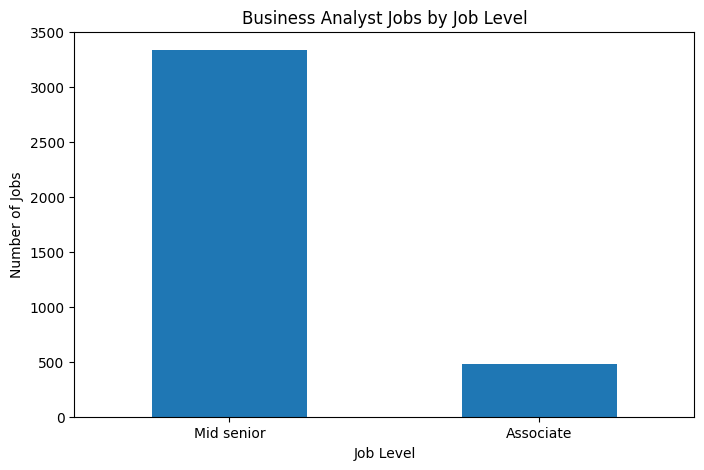

job_level
Mid senior    87.4
Associate     12.6
Name: proportion, dtype: float64


In [15]:
level_counts = ba_df["job_level"].value_counts()

plt.figure(figsize=(8, 5))
level_counts.plot(kind="bar")

plt.title("Business Analyst Jobs by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)

plt.show()

level_percentages = (
    ba_df["job_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print(level_percentages)

In [16]:
level_percentages = (
    ba_df["job_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print(level_percentages)

job_level
Mid senior    87.4
Associate     12.6
Name: proportion, dtype: float64


**BY COUNTRY**

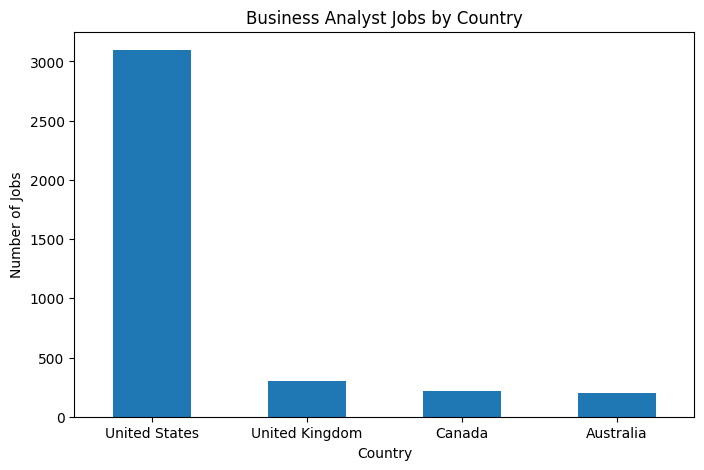

In [17]:
country_counts = ba_df["search_country"].value_counts()

plt.figure(figsize=(8, 5))
country_counts.plot(kind="bar")

plt.title("Business Analyst Jobs by Country")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)

plt.show()

In [18]:
country_percentages = (
    ba_df["search_country"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print(country_percentages)

search_country
United States     81.2
United Kingdom     7.9
Canada             5.7
Australia          5.2
Name: proportion, dtype: float64


**JOB TYPE**

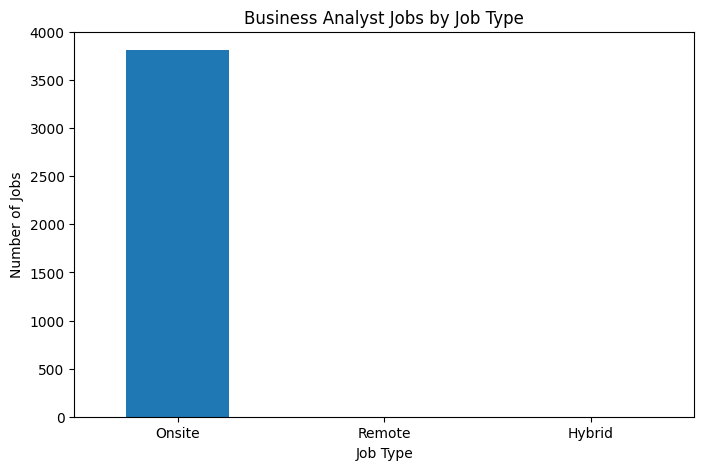

In [19]:
job_type_counts = ba_df["job_type"].value_counts()

plt.figure(figsize=(8, 5))
job_type_counts.plot(kind="bar")

plt.title("Business Analyst Jobs by Job Type")
plt.xlabel("Job Type")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)

plt.show()

In [20]:
job_type_percentages = (
    ba_df["job_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(job_type_percentages)

job_type
Onsite    99.95
Remote     0.03
Hybrid     0.03
Name: proportion, dtype: float64


**JOB TITLES**

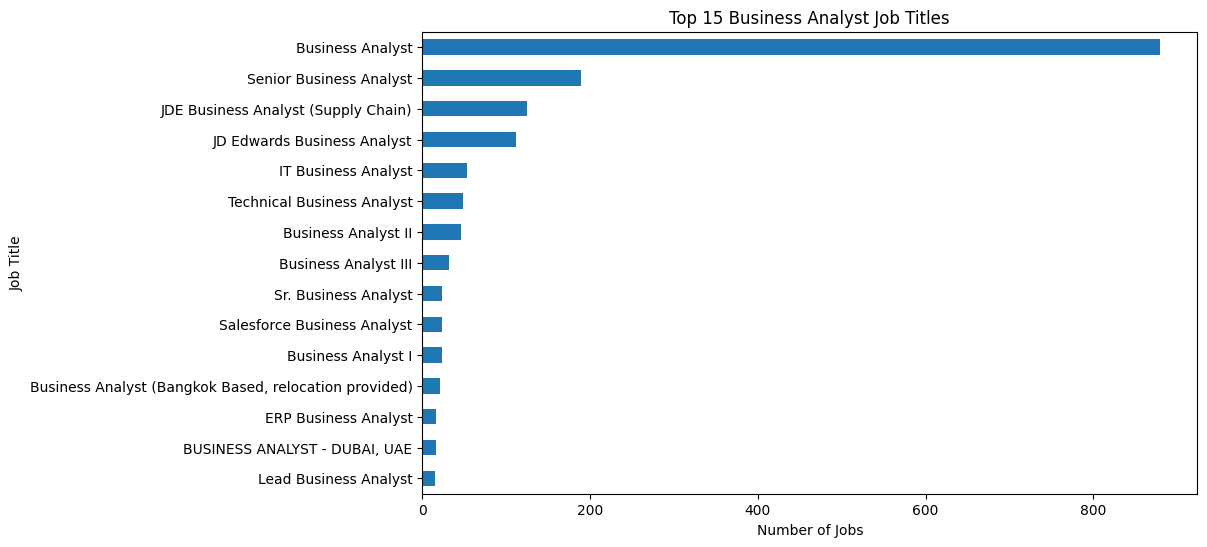

In [21]:
top_titles = ba_df["job_title"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_titles.sort_values().plot(kind="barh")

plt.title("Top 15 Business Analyst Job Titles")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Title")

plt.show()

In [22]:
print(top_titles)

job_title
Business Analyst                                         880
Senior Business Analyst                                  189
JDE Business Analyst (Supply Chain)                      125
JD Edwards Business Analyst                              112
IT Business Analyst                                       53
Technical Business Analyst                                48
Business Analyst II                                       46
Business Analyst III                                      32
Salesforce Business Analyst                               24
Business Analyst I                                        24
Sr. Business Analyst                                      24
Business Analyst (Bangkok Based, relocation provided)     21
BUSINESS ANALYST - DUBAI, UAE                             16
ERP Business Analyst                                      16
Lead Business Analyst                                     15
Name: count, dtype: int64


**LOCATION**

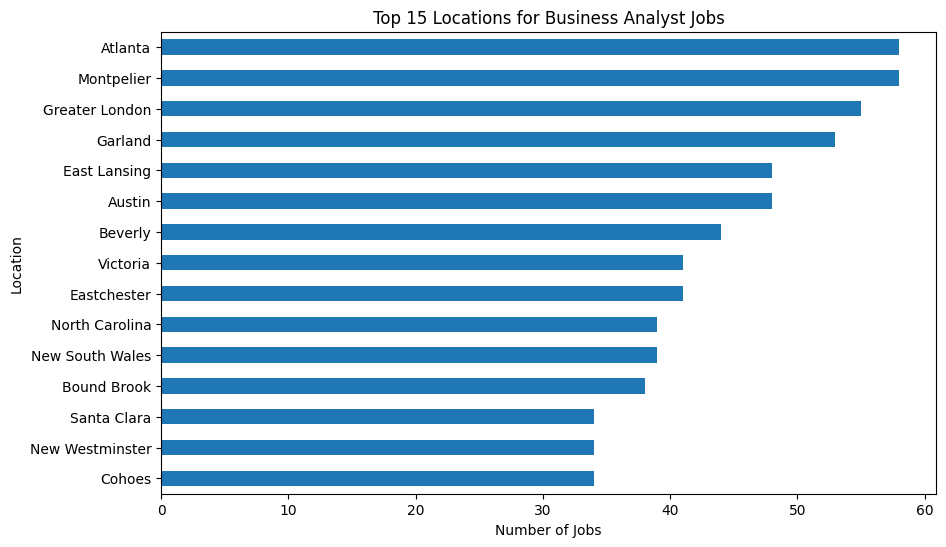

In [23]:
top_cities = ba_df["search_city"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_cities.sort_values().plot(kind="barh")

plt.title("Top 15 Locations for Business Analyst Jobs")
plt.xlabel("Number of Jobs")
plt.ylabel("Location")

plt.show()

In [24]:
print(top_cities)

search_city
Montpelier         58
Atlanta            58
Greater London     55
Garland            53
Austin             48
East Lansing       48
Beverly            44
Eastchester        41
Victoria           41
North Carolina     39
New South Wales    39
Bound Brook        38
New Westminster    34
Santa Clara        34
Cohoes             34
Name: count, dtype: int64


**COMPANIES**

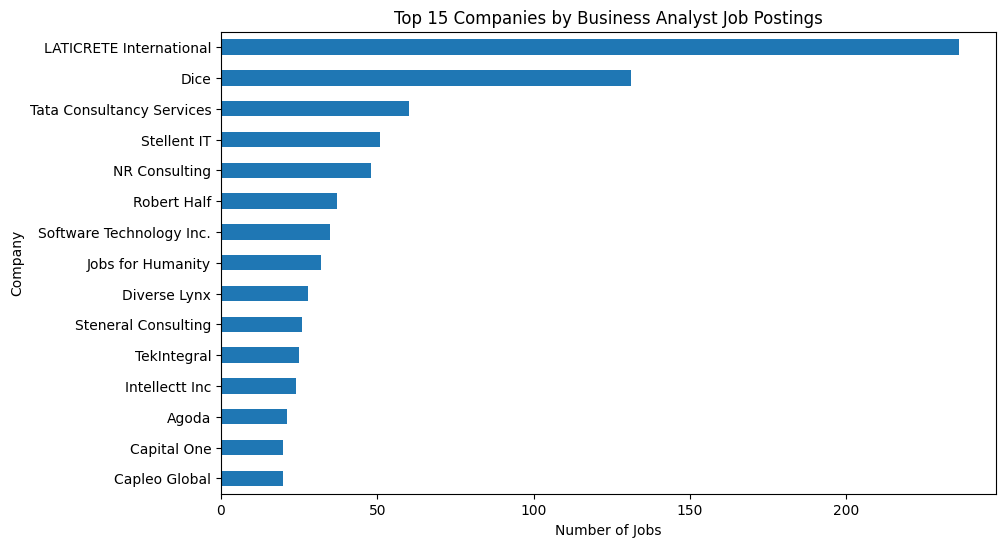

In [25]:
top_companies = ba_df["company"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_companies.sort_values().plot(kind="barh")

plt.title("Top 15 Companies by Business Analyst Job Postings")
plt.xlabel("Number of Jobs")
plt.ylabel("Company")

plt.show()

In [26]:
print(top_companies)

company
LATICRETE International      236
Dice                         131
Tata Consultancy Services     60
Stellent IT                   51
NR Consulting                 48
Robert Half                   37
Software Technology Inc.      35
Jobs for Humanity             32
Diverse Lynx                  28
Steneral Consulting           26
TekIntegral                   25
Intellectt Inc                24
Agoda                         21
Capleo Global                 20
Capital One                   20
Name: count, dtype: int64


**POSTING BY DATE**

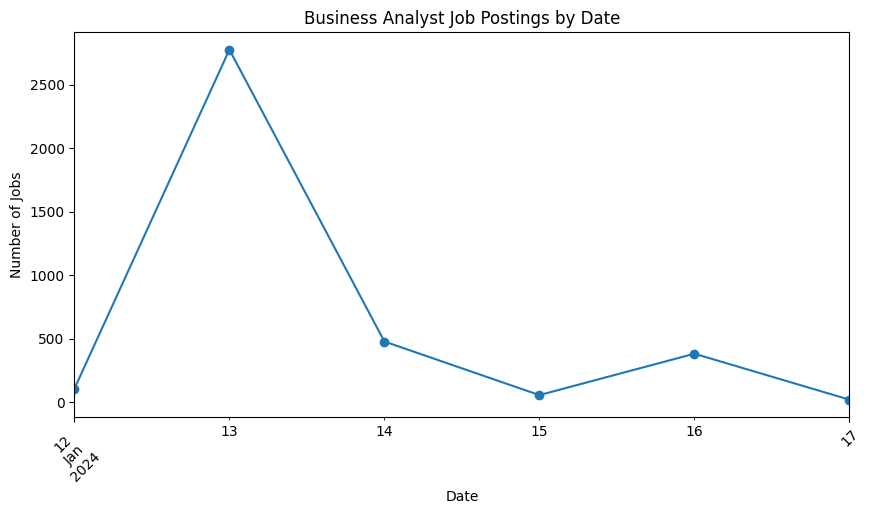

In [27]:
daily_ba = ba_df["first_seen"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
daily_ba.plot(kind="line", marker="o")

plt.title("Business Analyst Job Postings by Date")
plt.xlabel("Date")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

In [28]:
print(daily_ba)

first_seen
2024-01-12     105
2024-01-13    2776
2024-01-14     477
2024-01-15      55
2024-01-16     381
2024-01-17      19
Name: count, dtype: int64


In [29]:
level_country = pd.crosstab(
    ba_df["search_country"],
    ba_df["job_level"]
)

print(level_country)

job_level       Associate  Mid senior
search_country                       
Australia              10         188
Canada                 25         194
United Kingdom         19         281
United States         425        2671


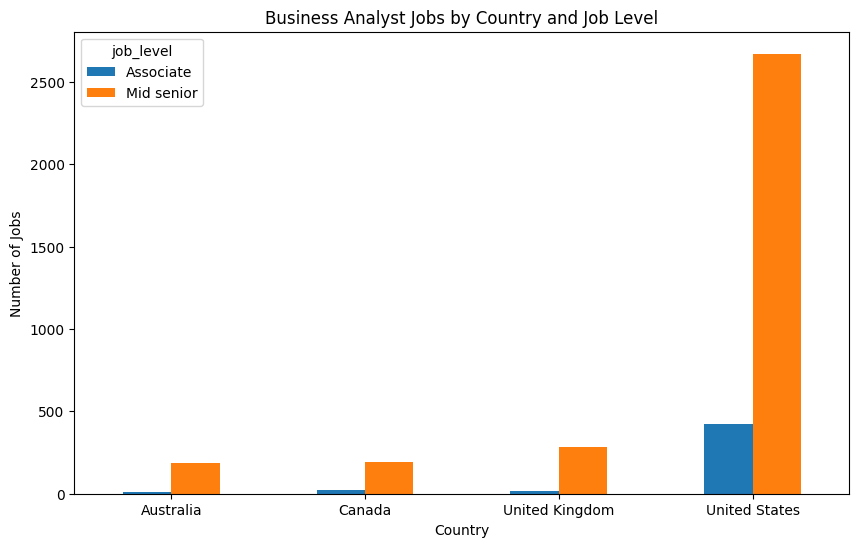

In [30]:
level_country.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Business Analyst Jobs by Country and Job Level")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=0)

plt.show()

In [34]:
skills_df = pd.read_csv("/content/job_skills.csv")

In [35]:
print("Rows:", len(skills_df))
print("Columns:", len(skills_df.columns))

print("\nMissing values:")
print(skills_df.isna().sum())

skills_df.head()

Rows: 331085
Columns: 2

Missing values:
job_link        0
job_skills    175
dtype: int64


,job_link,job_skills
0,https://www.linkedin.com/jobs/view/housekeeper...,"Building Custodial Services, Cleaning, Janitor..."
1,https://www.linkedin.com/jobs/view/assistant-g...,"Customer service, Restaurant management, Food ..."
2,https://www.linkedin.com/jobs/view/school-base...,"Applied Behavior Analysis (ABA), Data analysis..."
3,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Engineering, Project Controls, Sche..."
4,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Assembly, Point to point wiring, St..."


In [36]:
print("Duplicate rows:", skills_df.duplicated().sum())

print("Duplicate job_links:", skills_df["job_link"].duplicated().sum())

print("Unique job_links:", skills_df["job_link"].nunique())

Duplicate rows: 0
Duplicate job_links: 0
Unique job_links: 331085


In [37]:
print("Rows with missing skills:", skills_df["job_skills"].isna().sum())

print(
    "Percentage with missing skills:",
    round(skills_df["job_skills"].isna().mean() * 100, 2),
    "%"
)

Rows with missing skills: 175
Percentage with missing skills: 0.05 %


In [38]:
import pandas as pd
import numpy as np

jobs_df = pd.read_csv("linkedin_job_postings.csv")
skills_df = pd.read_csv("job_skills.csv")

print("MAIN JOBS:", jobs_df.shape)
print("JOB SKILLS:", skills_df.shape)

MAIN JOBS: (1048575, 14)
JOB SKILLS: (331085, 2)


In [39]:
print("MAIN JOBS:", jobs_df.shape)
print("JOB SKILLS:", skills_df.shape)

print("\n--- MAIN JOBS MISSING ---")
print(jobs_df.isna().sum())

print("\n--- JOB SKILLS MISSING ---")
print(skills_df.isna().sum())

print("\n--- MAIN JOBS DUPLICATES ---")
print("Duplicate rows:", jobs_df.duplicated().sum())
print("Duplicate job_links:", jobs_df["job_link"].duplicated().sum())

print("\n--- JOB SKILLS DUPLICATES ---")
print("Duplicate rows:", skills_df.duplicated().sum())
print("Duplicate job_links:", skills_df["job_link"].duplicated().sum())

MAIN JOBS: (1048575, 14)
JOB SKILLS: (331085, 2)

--- MAIN JOBS MISSING ---
job_link                0
last_processed_time     0
got_summary             0
got_ner                 0
is_being_worked         0
job_title               0
company                10
job_location           17
first_seen              0
search_city             0
search_country          0
search_position         0
job_level               0
job_type                0
dtype: int64

--- JOB SKILLS MISSING ---
job_link        0
job_skills    175
dtype: int64

--- MAIN JOBS DUPLICATES ---
Duplicate rows: 0
Duplicate job_links: 0

--- JOB SKILLS DUPLICATES ---
Duplicate rows: 0
Duplicate job_links: 0


In [40]:
print("MAIN DATASET MISSING %")
print((jobs_df.isna().mean() * 100).round(4))

print("\nJOB SKILLS MISSING %")
print((skills_df.isna().mean() * 100).round(4))

MAIN DATASET MISSING %
job_link               0.0000
last_processed_time    0.0000
got_summary            0.0000
got_ner                0.0000
is_being_worked        0.0000
job_title              0.0000
company                0.0010
job_location           0.0016
first_seen             0.0000
search_city            0.0000
search_country         0.0000
search_position        0.0000
job_level              0.0000
job_type               0.0000
dtype: float64

JOB SKILLS MISSING %
job_link      0.0000
job_skills    0.0529
dtype: float64


In [41]:
print("JOB LEVEL VALUES:")
print(jobs_df["job_level"].value_counts(dropna=False))

print("\nJOB TYPE VALUES:")
print(jobs_df["job_type"].value_counts(dropna=False))

print("\nCOUNTRY VALUES:")
print(jobs_df["search_country"].value_counts(dropna=False))

print("\nDATE RANGE:")
print("First:", jobs_df["first_seen"].min())
print("Last:", jobs_df["first_seen"].max())

JOB LEVEL VALUES:
job_level
Mid senior    924492
Associate     124083
Name: count, dtype: int64

JOB TYPE VALUES:
job_type
Onsite    1037787
Hybrid       6542
Remote       4246
Name: count, dtype: int64

COUNTRY VALUES:
search_country
United States     890986
United Kingdom     90931
Canada             43141
Australia          23517
Name: count, dtype: int64

DATE RANGE:
First: 12-01-2024
Last: 17-01-2024


In [42]:
print("JOB LEVEL %")
print((jobs_df["job_level"].value_counts(normalize=True) * 100).round(2))

print("\nJOB TYPE %")
print((jobs_df["job_type"].value_counts(normalize=True) * 100).round(2))

print("\nCOUNTRY %")
print((jobs_df["search_country"].value_counts(normalize=True) * 100).round(2))

JOB LEVEL %
job_level
Mid senior    88.17
Associate     11.83
Name: proportion, dtype: float64

JOB TYPE %
job_type
Onsite    98.97
Hybrid     0.62
Remote     0.40
Name: proportion, dtype: float64

COUNTRY %
search_country
United States     84.97
United Kingdom     8.67
Canada             4.11
Australia          2.24
Name: proportion, dtype: float64


In [43]:
skills_df["skill_count"] = (
    skills_df["job_skills"]
    .fillna("")
    .apply(lambda x: len([s for s in x.split(",") if s.strip()]))
)

print("Average skills per job:", round(skills_df["skill_count"].mean(), 2))
print("Minimum skills:", skills_df["skill_count"].min())
print("Maximum skills:", skills_df["skill_count"].max())

print("\nSkill count distribution:")
print(skills_df["skill_count"].describe())

Average skills per job: 21.1
Minimum skills: 0
Maximum skills: 415

Skill count distribution:
count    331085.000000
mean         21.095812
std          12.352326
min           0.000000
25%          13.000000
50%          19.000000
75%          26.000000
max         415.000000
Name: skill_count, dtype: float64


**JOB SUMMARY**

In [44]:
print(len(ba_df))
print(ba_df["job_link"].head())

3813
343     https://www.linkedin.com/jobs/view/secret-clea...
401     https://www.linkedin.com/jobs/view/business-an...
530     https://www.linkedin.com/jobs/view/payment-swi...
797     https://www.linkedin.com/jobs/view/principal-b...
1258    https://www.linkedin.com/jobs/view/business-an...
Name: job_link, dtype: object


In [45]:
ba_links = set(ba_df["job_link"].dropna())

print("BA links:", len(ba_links))

BA links: 3813


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [47]:
summary_file = "/content/drive/MyDrive/job_summary.csv"

**TRIMMING JOB SUMMARY TO BA RELATED**

In [48]:
import pandas as pd

output_file = "/content/BA_job_summary.csv"

first_chunk = True
matched_rows = 0

for chunk in pd.read_csv(
    summary_file,
    usecols=["job_link", "job_summary"],
    chunksize=100000
):

    matched = chunk[chunk["job_link"].isin(ba_links)]

    if len(matched) > 0:
        matched.to_csv(
            output_file,
            mode="w" if first_chunk else "a",
            header=first_chunk,
            index=False
        )
        first_chunk = False
        matched_rows += len(matched)

print("BA summaries extracted:", matched_rows)

BA summaries extracted: 3725


In [49]:
import pandas as pd

BA_job_summary = pd.read_csv("/content/BA_job_summary.csv")

print(BA_job_summary.shape)
print(BA_job_summary.head())

(3725, 2)
                                            job_link  \
0  https://www.linkedin.com/jobs/view/business-an...   
1  https://www.linkedin.com/jobs/view/business-an...   
2  https://au.linkedin.com/jobs/view/iam-business...   
3  https://au.linkedin.com/jobs/view/business-ana...   
4  https://www.linkedin.com/jobs/view/sr-business...   

                                         job_summary  
0  Title: Business Analyst I\nLocation: Purchase,...  
1  About The Opportunity\n“We believe that every ...  
2  Urgent requirement of\nIAM Business Analyst - ...  
3  3 months plus extensions\nBased in Darwin, NT\...  
4  Role: Sr. Business Analyst\nLocations: Irving,...  


**QUALITY ANALYSIS ON JOB SUMMARY**

In [50]:
print("Missing values:")
print(BA_job_summary.isna().sum())

print("\nDuplicate rows:")
print(BA_job_summary.duplicated().sum())

print("\nDuplicate job links:")
print(BA_job_summary["job_link"].duplicated().sum())

Missing values:
job_link       0
job_summary    0
dtype: int64

Duplicate rows:
0

Duplicate job links:
0


In [51]:
# Basic text quality assessment

BA_job_summary["summary_length"] = (
    BA_job_summary["job_summary"]
    .str.len()
)

print("Summary length statistics:")
print(BA_job_summary["summary_length"].describe())

print("\nEmpty summaries:")
print((BA_job_summary["summary_length"] == 0).sum())

print("\nVery short summaries (<100 characters):")
print((BA_job_summary["summary_length"] < 100).sum())

print("\nLongest summary:")
print(BA_job_summary["summary_length"].max())

Summary length statistics:
count     3725.000000
mean      3788.113289
std       2196.371592
min         99.000000
25%       2063.000000
50%       3510.000000
75%       5334.000000
max      13728.000000
Name: summary_length, dtype: float64

Empty summaries:
0

Very short summaries (<100 characters):
1

Longest summary:
13728


In [52]:
# Find BA postings that do not have a job summary

summary_links = set(BA_job_summary["job_link"])

ba_missing_summary = ba_df[
    ~ba_df["job_link"].isin(summary_links)
].copy()

print("BA postings without summary:", len(ba_missing_summary))

print("\nBy country:")
print(ba_missing_summary["search_country"].value_counts())

print("\nBy job level:")
print(ba_missing_summary["job_level"].value_counts())

BA postings without summary: 88

By country:
search_country
United States     74
Canada            10
United Kingdom     2
Australia          2
Name: count, dtype: int64

By job level:
job_level
Mid senior    85
Associate      3
Name: count, dtype: int64


In [53]:
# Missing summary rate by country

country_total = ba_df["search_country"].value_counts()

country_missing = ba_missing_summary["search_country"].value_counts()

country_missing_rate = (
    country_missing / country_total * 100
).fillna(0).round(2)

print("Missing summary rate by country:")
print(country_missing_rate)

Missing summary rate by country:
search_country
Australia         1.01
Canada            4.57
United Kingdom    0.67
United States     2.39
Name: count, dtype: float64


In [54]:
# Missing summary rate by job level

level_total = ba_df["job_level"].value_counts()

level_missing = ba_missing_summary["job_level"].value_counts()

level_missing_rate = (
    level_missing / level_total * 100
).fillna(0).round(2)

print("\nMissing summary rate by job level:")
print(level_missing_rate)


Missing summary rate by job level:
job_level
Mid senior    2.55
Associate     0.63
Name: count, dtype: float64


In [55]:
# Check whether summaries contain common requirement-related terms

terms = [
    "experience",
    "education",
    "degree",
    "bachelor",
    "skills",
    "requirements",
    "qualification"
]

for term in terms:
    count = BA_job_summary["job_summary"].str.contains(
        term,
        case=False,
        na=False,
        regex=False
    ).sum()

    percentage = count / len(BA_job_summary) * 100

    print(f"{term}: {count} ({percentage:.2f}%)")

experience: 3528 (94.71%)
education: 1342 (36.03%)
degree: 2158 (57.93%)
bachelor: 1825 (48.99%)
skills: 3058 (82.09%)
requirements: 2997 (80.46%)
qualification: 1708 (45.85%)


**relationship between the 3 datasets**

In [56]:
# Create sets of job links

ba_links = set(ba_df["job_link"].dropna())
skills_links = set(skills_df["job_link"].dropna())
summary_links = set(BA_job_summary["job_link"].dropna())

# BA jobs with skills
ba_with_skills = ba_links.intersection(skills_links)

# BA jobs with summaries
ba_with_summary = ba_links.intersection(summary_links)

# BA jobs with BOTH
ba_with_both = ba_links.intersection(skills_links, summary_links)

print("Total BA postings:", len(ba_links))
print("BA postings with skills:", len(ba_with_skills))
print("BA postings with summary:", len(ba_with_summary))
print("BA postings with BOTH:", len(ba_with_both))

Total BA postings: 3813
BA postings with skills: 1619
BA postings with summary: 3725
BA postings with BOTH: 1619


In [57]:
import pandas as pd

# Load datasets
df = pd.read_csv("/content/linkedin_job_postings.csv")
skills_df = pd.read_csv("/content/job_skills.csv")
summary_df = pd.read_csv("/content/BA_job_summary.csv")

# Select BA-related postings
ba_df = df[
    df["job_title"].str.contains(
        "business analyst",
        case=False,
        na=False,
        regex=False
    )
].copy()

# Keep relevant posting information
ba_postings = ba_df[
    [
        "job_link", "job_title", "company", "job_location",
        "first_seen", "search_city", "search_country",
        "search_position", "job_level", "job_type"
    ]
]

# Merge skills
ba_integrated = ba_postings.merge(
    skills_df[["job_link", "job_skills"]],
    on="job_link",
    how="left"
)

# Merge summaries
ba_integrated = ba_integrated.merge(
    summary_df[["job_link", "job_summary"]],
    on="job_link",
    how="left"
)

# Save Excel
output_path = "/content/BA_Integrated_Dataset.xlsx"
ba_integrated.to_excel(output_path, index=False)

print("Created successfully!")
print("Rows:", len(ba_integrated))
print("Columns:", len(ba_integrated.columns))
print("Missing skills:", ba_integrated["job_skills"].isna().sum())
print("Missing summaries:", ba_integrated["job_summary"].isna().sum())

Created successfully!
Rows: 3813
Columns: 12
Missing skills: 89
Missing summaries: 88


**INTEGRATED DATASET ON BA RELATED JOBS**

In [58]:
from google.colab import files
files.download("/content/BA_Integrated_Dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**COMPARING MY DATASET WITH TEAMMATE DATASET**

In [59]:
import pandas as pd

# Load datasets
full_df = pd.read_csv("/content/linkedin_job_postings.csv")
team_df = pd.read_csv("/content/business_analyst_jobs.csv")

# Our previous BA definition
our_ba_df = full_df[
    full_df["job_title"].str.contains(
        "business analyst",
        case=False,
        na=False,
        regex=False
    )
].copy()

print("OUR BA DATASET")
print("Rows:", len(our_ba_df))

print("\nTEAMMATE BA DATASET")
print("Rows:", len(team_df))

print("\nDIFFERENCE")
print("Additional records in teammate dataset:",
      len(team_df) - len(our_ba_df))

OUR BA DATASET
Rows: 3813

TEAMMATE BA DATASET
Rows: 4576

DIFFERENCE
Additional records in teammate dataset: 763


In [60]:
# Titles in teammate dataset that DO NOT contain
# the exact phrase "business analyst"

extra_titles = team_df[
    ~team_df["job_link"].isin(our_ba_df["job_link"])
]["job_title"]

print("Number of additional records:", len(extra_titles))

print("\nAdditional job titles:")
print(extra_titles.value_counts().head(100))

Number of additional records: 763

Additional job titles:
job_title
Business Analyst                                                                       131
JD Edwards Business Analyst                                                             38
JDE Business Analyst (Supply Chain)                                                     38
Senior Business Analyst                                                                 22
Technical Business Analyst                                                              12
                                                                                      ... 
IT Analyst Sr - Application Delivery Business Analyst                                    1
Junior Project Manager/Business Analyst                                                  1
Business Analyst, Associate or Business Analyst                                          1
Business Analyst - IBOR/Ops                                                              1
Immediate Need!! Busin

In [61]:
# Get the 763 records that are in your teammate's dataset
# but not in our original BA dataset

extra_df = team_df[
    ~team_df["job_link"].isin(our_ba_df["job_link"])
].copy()

print("Additional records:", len(extra_df))

# Show ALL unique additional job titles
print("\nNumber of unique additional titles:",
      extra_df["job_title"].nunique())

display(
    extra_df["job_title"]
    .value_counts()
    .reset_index()
    .rename(columns={
        "job_title": "Job Title",
        "count": "Count"
    })
)

Additional records: 763

Number of unique additional titles: 430


,Job Title,Count
0,Business Analyst,131
1,JD Edwards Business Analyst,38
2,JDE Business Analyst (Supply Chain),38
3,Senior Business Analyst,22
4,Technical Business Analyst,12
...,...,...
425,Business Analyst -ICT,1
426,Electronic Data Interchange (EDI) Business Ana...,1
427,Business Analyst – Procurement,1
428,Sr Financial/Business Analyst (REMOTE),1


In [62]:
# Check whether every additional title contains "analyst"
# and/or "business analyst"

extra_df["contains_business_analyst"] = (
    extra_df["job_title"]
    .str.contains("business analyst", case=False, na=False, regex=False)
)

extra_df["contains_analyst"] = (
    extra_df["job_title"]
    .str.contains("analyst", case=False, na=False, regex=False)
)

print("Contains 'Business Analyst':",
      extra_df["contains_business_analyst"].sum())

print("Contains 'Analyst':",
      extra_df["contains_analyst"].sum())

print("Contains neither:",
      (~extra_df["contains_analyst"]).sum())

Contains 'Business Analyst': 763
Contains 'Analyst': 763
Contains neither: 0


**SO WE WILL CONTINUE WITH THE DATASET WITH 4576 ROWS AS IT HAS SOME BA RELATED JOB LISTINGS THAT I HAVE MISSED**

In [64]:
import pandas as pd

jobs_df = pd.read_csv("/content/business_analyst_jobs.csv")
skills_df = pd.read_csv("/content/business_analyst_skills.csv")

print("BA jobs:", len(jobs_df))
print("BA skills:", len(skills_df))

# Job links that have skills
skill_links = set(skills_df["job_link"].dropna())

# BA jobs that have skills
jobs_with_skills = jobs_df[
    jobs_df["job_link"].isin(skill_links)
].copy()

print("BA jobs with skills:", len(jobs_with_skills))

BA jobs: 4576
BA skills: 4440
BA jobs with skills: 4440


In [65]:
# Save the required job links
required_links = jobs_with_skills[["job_link"]].drop_duplicates()

required_links.to_csv(
    "/content/required_BA_summary_links.csv",
    index=False
)

print("Required summary links:", len(required_links))
print("Saved required_BA_summary_links.csv")

Required summary links: 4440
Saved required_BA_summary_links.csv


In [66]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "job_summary.csv" in files:
        print(os.path.join(root, "job_summary.csv"))

/content/drive/MyDrive/job_summary.csv


In [67]:
import pandas as pd
import os

# Load the BA job links that we need summaries for
required_links = pd.read_csv(
    "/content/required_BA_summary_links.csv"
)

required_links_set = set(required_links["job_link"].dropna())

print("Job links required:", len(required_links_set))

# Original 49 GB summary file
summary_path = "/content/drive/MyDrive/job_summary.csv"

# Output file
output_path = "/content/business_analyst_summary.csv"

# Remove old output if it exists
if os.path.exists(output_path):
    os.remove(output_path)

found = 0
chunks_processed = 0

# Read the huge file in manageable chunks
for chunk in pd.read_csv(
    summary_path,
    usecols=["job_link", "job_summary"],
    chunksize=100000
):

    chunks_processed += 1

    # Keep only summaries for our required BA job links
    matched = chunk[
        chunk["job_link"].isin(required_links_set)
    ]

    if len(matched) > 0:
        matched.to_csv(
            output_path,
            mode="a",
            index=False,
            header=not os.path.exists(output_path)
        )

        found += len(matched)

    if chunks_processed % 10 == 0:
        print(
            f"Processed {chunks_processed} chunks | "
            f"Summaries found: {found}"
        )

print("\nExtraction complete.")
print("Total matching summaries found:", found)
print("Saved to:", output_path)


Job links required: 4440
Processed 10 chunks | Summaries found: 3486

Extraction complete.
Total matching summaries found: 4440
Saved to: /content/business_analyst_summary.csv


In [68]:
# Load the newly extracted summary dataset
summary_df = pd.read_csv("/content/business_analyst_summary.csv")

print("Summary rows:", len(summary_df))
print("Unique job links:", summary_df["job_link"].nunique())
print("Duplicate rows:", summary_df.duplicated().sum())
print("Duplicate job links:", summary_df["job_link"].duplicated().sum())

print("\nMissing values:")
print(summary_df.isna().sum())

print("\nSummary length statistics:")
summary_length = summary_df["job_summary"].str.len()

print(summary_length.describe())

Summary rows: 4440
Unique job links: 4440
Duplicate rows: 0
Duplicate job links: 0

Missing values:
job_link       0
job_summary    0
dtype: int64

Summary length statistics:
count     4440.000000
mean      3790.062387
std       2199.377154
min         99.000000
25%       2055.750000
50%       3510.000000
75%       5334.000000
max      17393.000000
Name: job_summary, dtype: float64


**INTEGRATING ALL THREE DATSETS WITH BA RELATED JOBS ONLY FOR TEAM TO WORK ON**

In [69]:
# Load the three datasets
jobs_df = pd.read_csv("/content/business_analyst_jobs.csv")
skills_df = pd.read_csv("/content/business_analyst_skills.csv")
summary_df = pd.read_csv("/content/business_analyst_summary.csv")

# Required job columns
jobs = jobs_df[
    [
        "job_link",
        "job_title",
        "company",
        "job_location",
        "search_city",
        "search_country",
        "job_level",
        "job_type",
        "first_seen"
    ]
].copy()

# Required skills column
skills = skills_df[
    ["job_link", "job_skills"]
].copy()

# Required summary columns
summaries = summary_df[
    ["job_link", "job_summary"]
].copy()

# Integrate all three datasets
integrated_df = (
    jobs
    .merge(skills, on="job_link", how="inner")
    .merge(summaries, on="job_link", how="inner")
)

# Final checks
print("Final integrated dataset")
print("=" * 50)
print("Rows:", len(integrated_df))
print("Columns:", len(integrated_df.columns))

print("\nMissing values:")
print(integrated_df.isna().sum())

print("\nDuplicate rows:", integrated_df.duplicated().sum())
print("Duplicate job_links:", integrated_df["job_link"].duplicated().sum())

display(integrated_df.head())

Final integrated dataset
Rows: 4440
Columns: 11

Missing values:
job_link          0
job_title         0
company           0
job_location      0
search_city       0
search_country    0
job_level         0
job_type          0
first_seen        0
job_skills        0
job_summary       0
dtype: int64

Duplicate rows: 0
Duplicate job_links: 0


,job_link,job_title,company,job_location,search_city,search_country,job_level,job_type,first_seen,job_skills,job_summary
0,https://www.linkedin.com/jobs/view/secret-clea...,Secret cleared Business Analyst,Latitude Inc,"Crystal City, VA",Virginia,United States,Mid senior,Onsite,2024-01-13,"Microsoft Office 365, Microsoft Teams, SharePo...",The work schedule is 8 hours a day Monday - Fr...
1,https://www.linkedin.com/jobs/view/business-an...,Business Analyst (11076-1),RAPS Consulting Inc,"Columbia, SC",Columbia,United States,Mid senior,Onsite,2024-01-14,"Technical Writing, Information Security, Micro...",Department of Health and Human Services\n1 - R...
2,https://www.linkedin.com/jobs/view/principal-b...,Principal Business Analyst,NextEra Energy Services,"Riviera Beach, FL",Palm Springs,United States,Mid senior,Onsite,2024-01-14,"NEER, FPL, Reliability reporting, GADS applica...",Requisition ID: 77096\nFlorida Power & Light C...
3,https://www.linkedin.com/jobs/view/salesforce-...,SalesForce Business Analyst,Treys Pte. Ltd.,"Washington, DC",Clinton,United States,Mid senior,Onsite,2024-01-17,"Business Analysis, Business Requirements Gathe...",Title:\nSalesForce Business Analyst\nLocation:...
4,https://www.linkedin.com/jobs/view/pricing-tra...,Pricing Transparency Analyst/CTrax Senior Busi...,CereCore,"Brentwood, TN",Nashville,United States,Mid senior,Onsite,2024-01-13,"Pricing Transparency Analyst, Data analysis, Q...",Classification: Contract\nContract Length: 12 ...


**FINAL INTEGRATED DATASET**

In [70]:
integrated_df.to_excel(
    "/content/Business_Analyst_Integrated_Dataset.xlsx",
    index=False
)

print("Saved successfully:")
print("/content/Business_Analyst_Integrated_Dataset.xlsx")

Saved successfully:
/content/Business_Analyst_Integrated_Dataset.xlsx


**DATA QUALITY ON DERIVED DATASET**

In [71]:
# Load final integrated dataset

integrated_df = pd.read_excel(
    "/content/Business_Analyst_Integrated_Dataset.xlsx"
)

print("=" * 70)
print("DATA QUALITY ASSESSMENT — DATASET STRUCTURE")
print("=" * 70)

print("\nDataset dimensions:")
print("Rows:", integrated_df.shape[0])
print("Columns:", integrated_df.shape[1])

print("\nColumn names:")
print(integrated_df.columns.tolist())

print("\nData types:")
display(
    integrated_df.dtypes.to_frame("Data Type")
)

print("\nDuplicate rows:")
print(integrated_df.duplicated().sum())

print("\nDuplicate job_links:")
print(integrated_df["job_link"].duplicated().sum())

print("\nMissing values:")
missing = integrated_df.isna().sum().to_frame("Missing Values")
missing["Missing %"] = (
    missing["Missing Values"] / len(integrated_df) * 100
).round(2)

display(missing)

DATA QUALITY ASSESSMENT — DATASET STRUCTURE

Dataset dimensions:
Rows: 4440
Columns: 11

Column names:
['job_link', 'job_title', 'company', 'job_location', 'search_city', 'search_country', 'job_level', 'job_type', 'first_seen', 'job_skills', 'job_summary']

Data types:


,Data Type
job_link,object
job_title,object
company,object
job_location,object
search_city,object
search_country,object
job_level,object
job_type,object
first_seen,object
job_skills,object



Duplicate rows:
0

Duplicate job_links:
0

Missing values:


,Missing Values,Missing %
job_link,0,0.0
job_title,0,0.0
company,0,0.0
job_location,0,0.0
search_city,0,0.0
search_country,0,0.0
job_level,0,0.0
job_type,0,0.0
first_seen,0,0.0
job_skills,0,0.0


In [72]:
# Compare the original BA jobs dataset with the final integrated dataset

original_jobs = pd.read_csv(
    "/content/business_analyst_jobs.csv"
)

integrated_links = set(integrated_df["job_link"])

original_links = set(original_jobs["job_link"])

# Jobs excluded from the integrated dataset
excluded_jobs = original_jobs[
    ~original_jobs["job_link"].isin(integrated_links)
].copy()

print("=" * 70)
print("INTEGRATION COVERAGE")
print("=" * 70)

print("\nOriginal BA jobs:", len(original_jobs))
print("Final integrated jobs:", len(integrated_df))
print("Excluded jobs:", len(excluded_jobs))

print("\nIntegration coverage:",
      round(len(integrated_df) / len(original_jobs) * 100, 2), "%")

print("Excluded percentage:",
      round(len(excluded_jobs) / len(original_jobs) * 100, 2), "%")

INTEGRATION COVERAGE

Original BA jobs: 4576
Final integrated jobs: 4440
Excluded jobs: 136

Integration coverage: 97.03 %
Excluded percentage: 2.97 %


In [73]:
# Determine whether the 136 excluded jobs were missing
# skills, summaries, or both

skill_links = set(skills_df["job_link"])
summary_links = set(summary_df["job_link"])

excluded_jobs["Has Skills"] = (
    excluded_jobs["job_link"].isin(skill_links)
)

excluded_jobs["Has Summary"] = (
    excluded_jobs["job_link"].isin(summary_links)
)

# Classify exclusion reason
def classify_exclusion(row):
    if not row["Has Skills"] and not row["Has Summary"]:
        return "Missing both skills and summary"
    elif not row["Has Skills"]:
        return "Missing skills"
    elif not row["Has Summary"]:
        return "Missing summary"
    else:
        return "Other"

excluded_jobs["Exclusion Reason"] = excluded_jobs.apply(
    classify_exclusion,
    axis=1
)

print("\nExclusion reasons:")
print(
    excluded_jobs["Exclusion Reason"]
    .value_counts()
)


Exclusion reasons:
Exclusion Reason
Missing both skills and summary    136
Name: count, dtype: int64


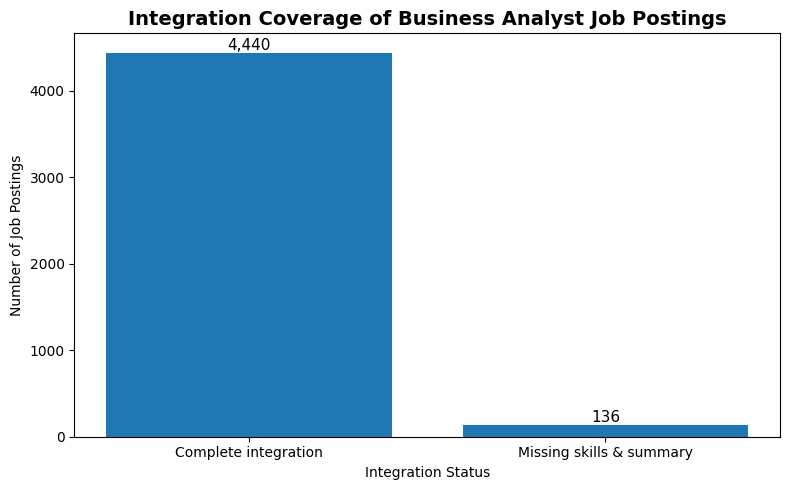

Saved:
/content/DQ_Figure_1_Integration_Coverage.png


In [74]:
import matplotlib.pyplot as plt

# Integration coverage data
labels = [
    "Complete integration",
    "Missing skills & summary"
]

values = [4440, 136]

# Create chart
plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.title(
    "Integration Coverage of Business Analyst Job Postings",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Job Postings")
plt.xlabel("Integration Status")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

# Save high-resolution PNG
plt.savefig(
    "/content/DQ_Figure_1_Integration_Coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("/content/DQ_Figure_1_Integration_Coverage.png")

In [75]:
# Completeness assessment

completeness = pd.DataFrame({
    "Variable": integrated_df.columns,
    "Non-Missing": integrated_df.notna().sum().values,
    "Missing": integrated_df.isna().sum().values
})

completeness["Completeness (%)"] = (
    completeness["Non-Missing"] / len(integrated_df) * 100
).round(2)

completeness["Missing (%)"] = (
    completeness["Missing"] / len(integrated_df) * 100
).round(2)

display(completeness)

,Variable,Non-Missing,Missing,Completeness (%),Missing (%)
0,job_link,4440,0,100.0,0.0
1,job_title,4440,0,100.0,0.0
2,company,4440,0,100.0,0.0
3,job_location,4440,0,100.0,0.0
4,search_city,4440,0,100.0,0.0
5,search_country,4440,0,100.0,0.0
6,job_level,4440,0,100.0,0.0
7,job_type,4440,0,100.0,0.0
8,first_seen,4440,0,100.0,0.0
9,job_skills,4440,0,100.0,0.0


In [76]:
completeness.to_csv(
    "/content/DQ_Completeness_Table.csv",
    index=False
)

print("Saved: DQ_Completeness_Table.csv")

Saved: DQ_Completeness_Table.csv


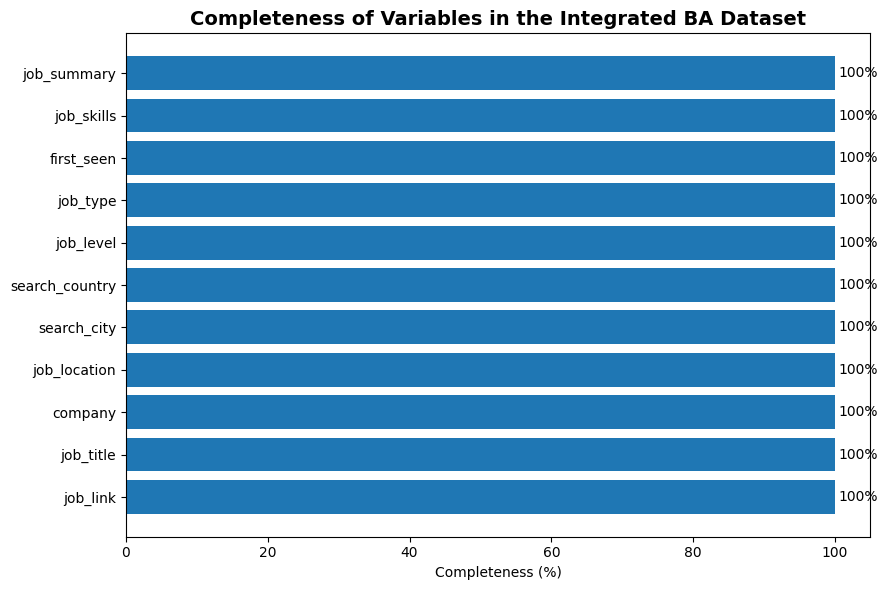

Saved: DQ_Figure_2_Completeness.png


In [77]:
import matplotlib.pyplot as plt

# Sort variables for a clean presentation
plot_df = completeness.sort_values("Completeness (%)")

plt.figure(figsize=(9, 6))

bars = plt.barh(
    plot_df["Variable"],
    plot_df["Completeness (%)"]
)

plt.title(
    "Completeness of Variables in the Integrated BA Dataset",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Completeness (%)")
plt.xlim(0, 105)

# Add percentage labels
for bar, value in zip(bars, plot_df["Completeness (%)"]):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "/content/DQ_Figure_2_Completeness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: DQ_Figure_2_Completeness.png")

In [78]:
# Uniqueness assessment

uniqueness = pd.DataFrame({
    "Check": [
        "Total records",
        "Unique job links",
        "Duplicate job links",
        "Duplicate rows"
    ],
    "Count": [
        len(integrated_df),
        integrated_df["job_link"].nunique(),
        integrated_df["job_link"].duplicated().sum(),
        integrated_df.duplicated().sum()
    ]
})

display(uniqueness)

,Check,Count
0,Total records,4440
1,Unique job links,4440
2,Duplicate job links,0
3,Duplicate rows,0


In [79]:
uniqueness_rate = (
    integrated_df["job_link"].nunique()
    / len(integrated_df)
    * 100
)

print(f"Job-link uniqueness: {uniqueness_rate:.2f}%")

Job-link uniqueness: 100.00%


In [80]:
uniqueness.to_csv(
    "/content/DQ_Uniqueness_Table.csv",
    index=False
)

print("Saved: DQ_Uniqueness_Table.csv")

Saved: DQ_Uniqueness_Table.csv


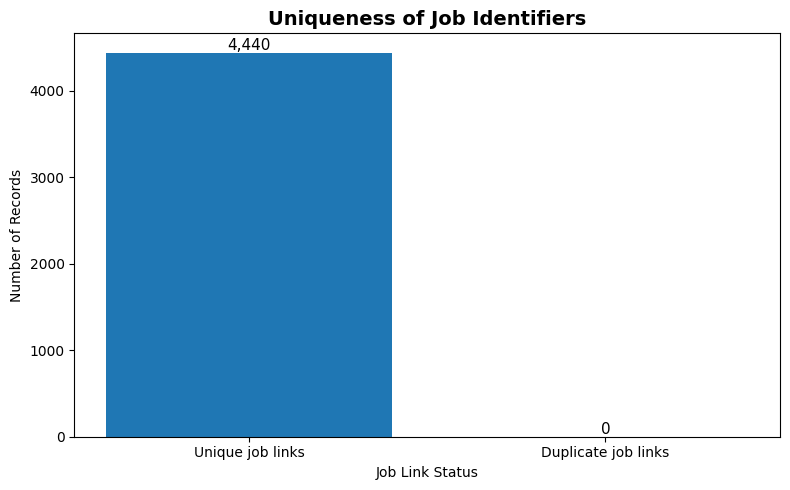

Saved: DQ_Figure_3_Uniqueness.png


In [81]:
import matplotlib.pyplot as plt

unique_count = integrated_df["job_link"].nunique()
duplicate_count = integrated_df["job_link"].duplicated().sum()

labels = [
    "Unique job links",
    "Duplicate job links"
]

values = [
    unique_count,
    duplicate_count
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.title(
    "Uniqueness of Job Identifiers",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Records")
plt.xlabel("Job Link Status")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "/content/DQ_Figure_3_Uniqueness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: DQ_Figure_3_Uniqueness.png")

In [82]:
# Validity and consistency assessment

categorical_columns = [
    "job_level",
    "job_type",
    "search_country"
]

for column in categorical_columns:
    print("=" * 60)
    print(column)
    print("=" * 60)
    print("Number of unique values:", integrated_df[column].nunique())
    print("\nValues and frequencies:")
    print(integrated_df[column].value_counts(dropna=False))
    print()

job_level
Number of unique values: 2

Values and frequencies:
job_level
Mid senior    3926
Associate      514
Name: count, dtype: int64

job_type
Number of unique values: 3

Values and frequencies:
job_type
Onsite    4438
Remote       1
Hybrid       1
Name: count, dtype: int64

search_country
Number of unique values: 4

Values and frequencies:
search_country
United States     3638
United Kingdom     335
Canada             246
Australia          221
Name: count, dtype: int64



In [83]:
# Check first_seen date validity

date_test = pd.to_datetime(
    integrated_df["first_seen"],
    errors="coerce",
    dayfirst=False
)

print("Original data type:")
print(integrated_df["first_seen"].dtype)

print("\nInvalid dates:")
print(date_test.isna().sum())

print("\nDate range:")
print("Minimum:", date_test.min())
print("Maximum:", date_test.max())

print("\nUnique dates:")
print(
    date_test.dt.strftime("%d-%m-%Y")
    .value_counts()
    .sort_index()
)

Original data type:
object

Invalid dates:
0

Date range:
Minimum: 2024-01-12 00:00:00
Maximum: 2024-01-17 00:00:00

Unique dates:
first_seen
12-01-2024     107
13-01-2024    2950
14-01-2024     756
15-01-2024      84
16-01-2024     508
17-01-2024      35
Name: count, dtype: int64


In [84]:
# Test the expected DD-MM-YYYY format

date_correct = pd.to_datetime(
    integrated_df["first_seen"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Invalid dates using DD-MM-YYYY:",
      date_correct.isna().sum())

print("\nCorrect date range:")
print("Minimum:", date_correct.min())
print("Maximum:", date_correct.max())

print("\nDates and frequencies:")
print(
    date_correct.dt.strftime("%d %b %Y")
    .value_counts()
    .sort_index()
)

Invalid dates using DD-MM-YYYY: 4440

Correct date range:
Minimum: NaT
Maximum: NaT

Dates and frequencies:
Series([], Name: count, dtype: int64)


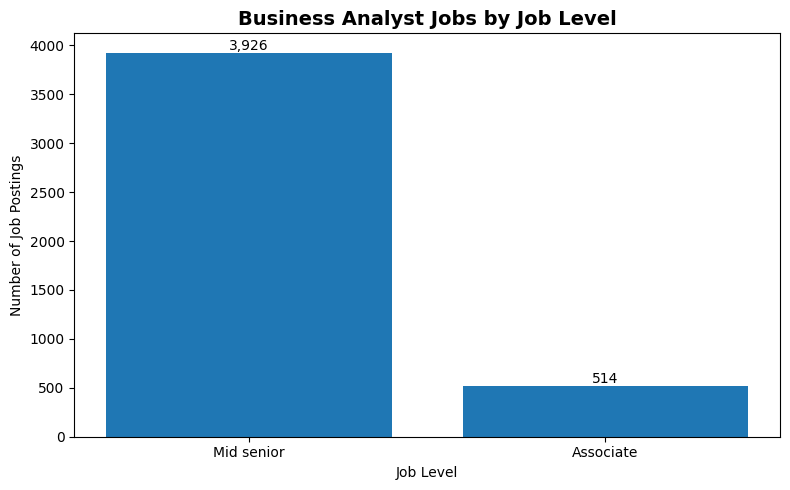

Saved: DQ_Figure_4_Job_Level.png


In [85]:
import matplotlib.pyplot as plt

level_counts = integrated_df["job_level"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    level_counts.index,
    level_counts.values
)

plt.title(
    "Business Analyst Jobs by Job Level",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Job Level")
plt.ylabel("Number of Job Postings")

for bar, value in zip(bars, level_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "/content/DQ_Figure_4_Job_Level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: DQ_Figure_4_Job_Level.png")


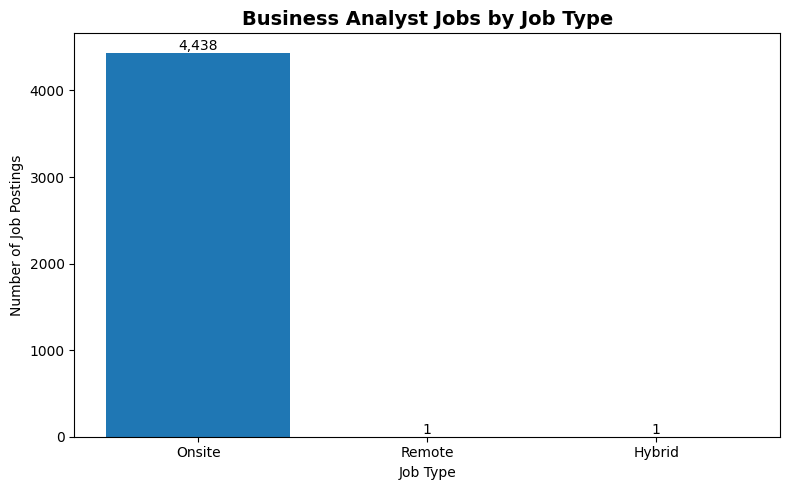

Saved: DQ_Figure_5_Job_Type.png


In [86]:
job_type_counts = integrated_df["job_type"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    job_type_counts.index,
    job_type_counts.values
)

plt.title(
    "Business Analyst Jobs by Job Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")

for bar, value in zip(bars, job_type_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "/content/DQ_Figure_5_Job_Type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: DQ_Figure_5_Job_Type.png")

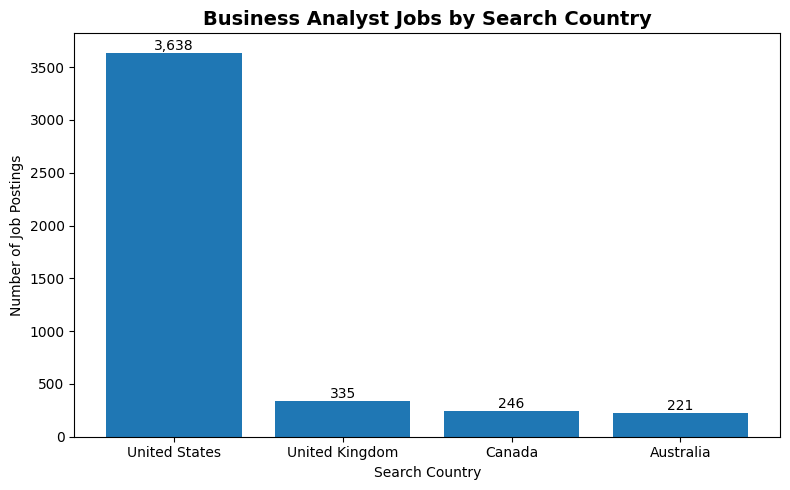

Saved: DQ_Figure_6_Search_Country.png


In [87]:
country_counts = integrated_df["search_country"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    country_counts.index,
    country_counts.values
)

plt.title(
    "Business Analyst Jobs by Search Country",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Search Country")
plt.ylabel("Number of Job Postings")

for bar, value in zip(bars, country_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "/content/DQ_Figure_6_Search_Country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: DQ_Figure_6_Search_Country.png")

In [88]:
# Convert first_seen to a proper datetime variable
integrated_df["first_seen_date"] = pd.to_datetime(
    integrated_df["first_seen"],
    errors="coerce"
)

# Check date validity
print("Invalid dates:", integrated_df["first_seen_date"].isna().sum())

print("\nDate range:")
print("Earliest:", integrated_df["first_seen_date"].min())
print("Latest:", integrated_df["first_seen_date"].max())

# Count jobs by date
date_counts = (
    integrated_df["first_seen_date"]
    .value_counts()
    .sort_index()
)

display(
    date_counts.to_frame("Number of Job Postings")
)

Invalid dates: 0

Date range:
Earliest: 2024-01-12 00:00:00
Latest: 2024-01-17 00:00:00


,Number of Job Postings
first_seen_date,
2024-01-12,107
2024-01-13,2950
2024-01-14,756
2024-01-15,84
2024-01-16,508
2024-01-17,35


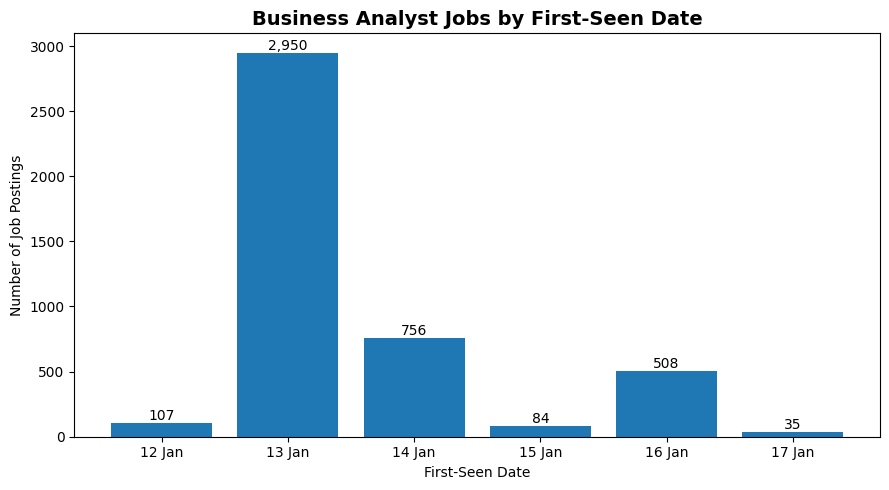

Saved: DQ_Figure_7_Timeliness.png


In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

bars = plt.bar(
    date_counts.index.strftime("%d %b"),
    date_counts.values
)

plt.title(
    "Business Analyst Jobs by First-Seen Date",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("First-Seen Date")
plt.ylabel("Number of Job Postings")

for bar, value in zip(bars, date_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "/content/DQ_Figure_7_Timeliness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: DQ_Figure_7_Timeliness.png")

In [90]:
# Calculate number of skills recorded for each job

integrated_df["skill_count"] = (
    integrated_df["job_skills"]
    .fillna("")
    .apply(
        lambda x: len([
            skill.strip()
            for skill in x.split(",")
            if skill.strip()
        ])
    )
)

print("Skill count statistics")
print("=" * 50)

print(
    integrated_df["skill_count"].describe()
)

Skill count statistics
count    4440.000000
mean       25.011937
std        15.187603
min         1.000000
25%        16.000000
50%        22.000000
75%        29.000000
max       163.000000
Name: skill_count, dtype: float64


In [91]:
zero_skills = integrated_df[
    integrated_df["skill_count"] == 0
]

print("Jobs with zero recorded skills:",
      len(zero_skills))

print(
    "Percentage:",
    round(
        len(zero_skills) / len(integrated_df) * 100,
        2
    ),
    "%"
)

Jobs with zero recorded skills: 0
Percentage: 0.0 %


In [92]:
# Examine jobs with unusually high skill counts

print("Top 20 jobs by number of recorded skills:")
print("=" * 60)

display(
    integrated_df[
        [
            "job_title",
            "company",
            "skill_count",
            "job_skills"
        ]
    ]
    .sort_values(
        "skill_count",
        ascending=False
    )
    .head(20)
)

Top 20 jobs by number of recorded skills:


,job_title,company,skill_count,job_skills
1649,Computer Vision Business Analyst,Georgia-Pacific LLC,163,"Business Analyst, Data engineering, Advanced a..."
217,JDE Business Analyst (Supply Chain),LATICRETE International,136,"JDE Edwards, Supply Chain Management, Discrete..."
1733,JDE Business Analyst (Supply Chain),LATICRETE International,133,"Discrete & Lean Manufacturing, Product Data Ma..."
3737,JDE Business Analyst (Supply Chain),LATICRETE International,120,"JD Edwards, Supply Chain Management, Business ..."
119,JDE Business Analyst (Supply Chain),LATICRETE International,118,"JDE Edwards, Supply Chain Management, JDE Busi..."
669,JDE Business Analyst (Supply Chain),LATICRETE International,117,"Discrete Manufacturing, Lean Manufacturing, Pr..."
4134,JDE Business Analyst (Supply Chain),LATICRETE International,114,"JDE Edwards, Supply Chain Management, Business..."
3546,JDE Business Analyst (Supply Chain),LATICRETE International,113,"Discrete & Lean Manufacturing, Product Data Ma..."
2438,Business Analyst,Siemens,112,"Accounting, Financial analysis, IFRS, SAP, Pow..."
1665,"Business Analyst – Senior Consultant, Banking ...",Cognizant,112,"Business Analyst, Senior Consultant, Cognizant..."


In [93]:
def count_duplicate_skills(skill_text):
    skills = [
        skill.strip().lower()
        for skill in str(skill_text).split(",")
        if skill.strip()
    ]

    return len(skills) - len(set(skills))


integrated_df["duplicate_skill_count"] = (
    integrated_df["job_skills"]
    .apply(count_duplicate_skills)
)

print(
    "Jobs containing duplicate skills:",
    (integrated_df["duplicate_skill_count"] > 0).sum()
)

print(
    "Total duplicate skill entries:",
    integrated_df["duplicate_skill_count"].sum()
)

Jobs containing duplicate skills: 435
Total duplicate skill entries: 779


In [94]:
# Show examples of jobs containing duplicate skills

duplicate_examples = integrated_df[
    integrated_df["duplicate_skill_count"] > 0
][[
    "job_title",
    "company",
    "skill_count",
    "duplicate_skill_count",
    "job_skills"
]].copy()

print("Jobs with duplicate skills:",
      len(duplicate_examples))

print("\nTop examples:")
display(
    duplicate_examples
    .sort_values(
        "duplicate_skill_count",
        ascending=False
    )
    .head(20)
)

Jobs with duplicate skills: 435

Top examples:


,job_title,company,skill_count,duplicate_skill_count,job_skills
3366,"Senior Business Analyst, Informatics/Business ...",Provincial Health Services Authority,79,20,"Business Analysis, Data Analytics, Reporting, ..."
1368,Sr. Healthcare Business Analyst (Interoperabil...,Procom,85,16,"* Artificial Intelligence, * Machine Learning,..."
1633,"Sr. Business Analyst, TOMY Driving Analytics",Amazon,60,12,"Data Mining, Data Modeling, VBA, SQL, Excel, T..."
416,IT Sr. Business Analyst (Salesforce),Leaf Home,47,12,"Netsuite, Salesforce, ERP Systems, MS Office S..."
3583,"Business Analyst (Bangkok Based, relocation pr...",Agoda,25,9,"Data analysis, SQL, Data analytics, Analytics,..."
2732,"Business Analyst (Bangkok Based, relocation pr...",Agoda,27,9,"Data analysis, SQL, Data analytics, Analytics,..."
1142,Business Analyst,Manhattan District Attorney's Office,34,8,"Business Analyst, Requirements gathering, Proj..."
1733,JDE Business Analyst (Supply Chain),LATICRETE International,133,8,"Discrete & Lean Manufacturing, Product Data Ma..."
2438,Business Analyst,Siemens,112,7,"Accounting, Financial analysis, IFRS, SAP, Pow..."
2030,"Senior Business Analyst, Underwriting",MEMIC,36,7,"Project Management, Business Analysis, Require..."


In [95]:
duplicate_job_percentage = (
    (integrated_df["duplicate_skill_count"] > 0).sum()
    / len(integrated_df)
    * 100
)

print(
    f"Percentage of jobs containing duplicate skills: "
    f"{duplicate_job_percentage:.2f}%"
)

print(
    "Total duplicate skill entries:",
    integrated_df["duplicate_skill_count"].sum()
)

Percentage of jobs containing duplicate skills: 9.80%
Total duplicate skill entries: 779


In [96]:
def count_unique_skills(skill_text):
    skills = [
        skill.strip().lower()
        for skill in str(skill_text).split(",")
        if skill.strip()
    ]

    return len(set(skills))


integrated_df["unique_skill_count"] = (
    integrated_df["job_skills"]
    .apply(count_unique_skills)
)

integrated_df["skill_count_difference"] = (
    integrated_df["skill_count"]
    - integrated_df["unique_skill_count"]
)

print("Total duplicate skill entries:",
      integrated_df["skill_count_difference"].sum())

print(
    "\nJobs affected:",
    (integrated_df["skill_count_difference"] > 0).sum()
)

print(
    "Average duplicate entries among affected jobs:",
    round(
        integrated_df.loc[
            integrated_df["skill_count_difference"] > 0,
            "skill_count_difference"
        ].mean(),
        2
    )
)

Total duplicate skill entries: 779

Jobs affected: 435
Average duplicate entries among affected jobs: 1.79


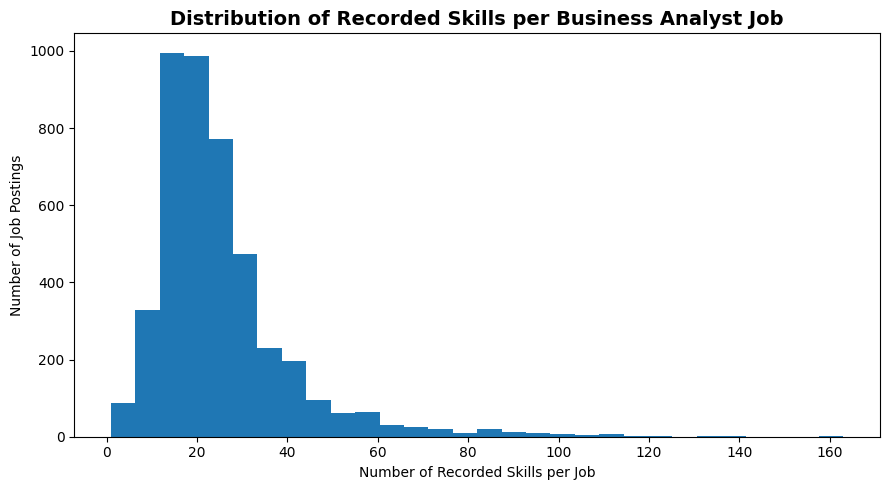

Saved: DQ_Figure_8_Skill_Count_Distribution.png


In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    integrated_df["skill_count"],
    bins=30
)

plt.title(
    "Distribution of Recorded Skills per Business Analyst Job",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Recorded Skills per Job")
plt.ylabel("Number of Job Postings")

plt.tight_layout()

plt.savefig(
    "/content/DQ_Figure_8_Skill_Count_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: DQ_Figure_8_Skill_Count_Distribution.png")

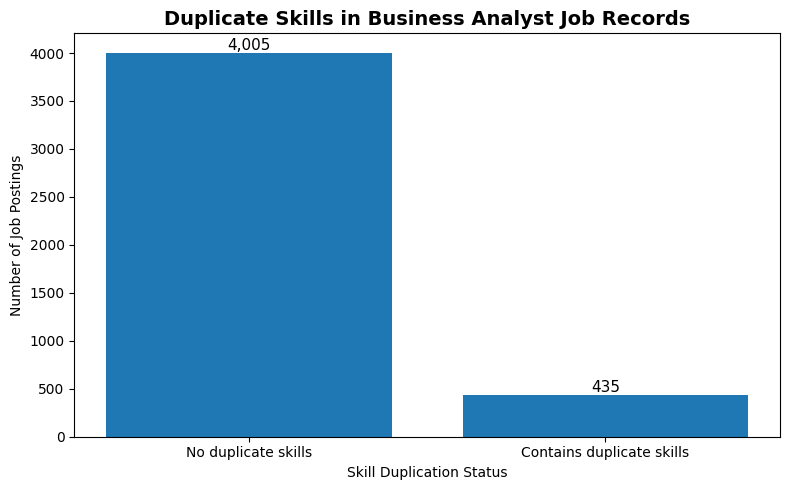

Saved: DQ_Figure_9_Duplicate_Skills.png


In [98]:
import matplotlib.pyplot as plt

duplicate_jobs = (
    integrated_df["duplicate_skill_count"] > 0
).sum()

no_duplicate_jobs = (
    integrated_df["duplicate_skill_count"] == 0
).sum()

labels = [
    "No duplicate skills",
    "Contains duplicate skills"
]

values = [
    no_duplicate_jobs,
    duplicate_jobs
]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.title(
    "Duplicate Skills in Business Analyst Job Records",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Skill Duplication Status")
plt.ylabel("Number of Job Postings")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "/content/DQ_Figure_9_Duplicate_Skills.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: DQ_Figure_9_Duplicate_Skills.png")

In [99]:
# Geographic data quality assessment

location_columns = [
    "job_location",
    "search_city",
    "search_country"
]

print("=" * 70)
print("GEOGRAPHIC DATA QUALITY")
print("=" * 70)

for column in location_columns:
    print(f"\n{column}")
    print("-" * 50)
    print("Unique values:", integrated_df[column].nunique())
    print("Missing values:", integrated_df[column].isna().sum())
    print("Blank values:",
          (integrated_df[column].astype(str).str.strip() == "").sum())

GEOGRAPHIC DATA QUALITY

job_location
--------------------------------------------------
Unique values: 1090
Missing values: 0
Blank values: 0

search_city
--------------------------------------------------
Unique values: 541
Missing values: 0
Blank values: 0

search_country
--------------------------------------------------
Unique values: 4
Missing values: 0
Blank values: 0


In [100]:
# Most frequent job locations

print("=" * 70)
print("TOP JOB LOCATIONS")
print("=" * 70)

display(
    integrated_df["job_location"]
    .value_counts()
    .head(20)
    .to_frame("Number of Jobs")
)

TOP JOB LOCATIONS


,Number of Jobs
job_location,
"New York, NY",104
"Atlanta, GA",81
"Boston, MA",78
"London, England, United Kingdom",66
"Chicago, IL",64
"Dallas, TX",55
"Richmond, VA",54
"Austin, TX",54
"Washington, DC",53


In [101]:
print("=" * 70)
print("TOP SEARCH CITIES")
print("=" * 70)

display(
    integrated_df["search_city"]
    .value_counts()
    .head(20)
    .to_frame("Number of Jobs")
)

TOP SEARCH CITIES


,Number of Jobs
search_city,
Greater London,61
Montpelier,59
Atlanta,59
Garland,57
Austin,56
East Lansing,53
North Carolina,47
Victoria,46
Beverly,46


In [102]:
print("=" * 70)
print("SEARCH COUNTRY VALUES")
print("=" * 70)

display(
    integrated_df["search_country"]
    .value_counts()
    .to_frame("Number of Jobs")
)

SEARCH COUNTRY VALUES


,Number of Jobs
search_country,
United States,3638
United Kingdom,335
Canada,246
Australia,221
